In [2]:
%matplotlib ipympl

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# load data
# data from initial RNN training
og_data = np.load("../data/fig2/experiment_results.npy", allow_pickle=True).item()
# data from re-learning after perturbation
pert_data = np.load("../data/fig2/relearning_results.npy", allow_pickle=True).item()

In [5]:
og_manifold = og_data["manifold"]["activity2"]
og_trial_order = og_data["manifold"]["order"]
omp_manifold = pert_data["manifold"]["within"]["activity"].reshape(50, -1, 800)
omp_trial_order = pert_data["manifold"]["within"]["order"]
wmp_manifold = pert_data["manifold"]["outside"]["activity"].reshape(50, -1, 800)
wmp_trial_order = pert_data["manifold"]["outside"]["order"]

In [6]:
# manifold shape: (trials, timesteps, neurons)
og_manifold.shape

(50, 180, 800)

In [7]:
manifold = {
  "original": {
      "activity": og_manifold,
      "order": og_trial_order
    },
  "within": {
      "activity": omp_manifold,
      "order": omp_trial_order
    },
  "outside": {
      "activity": wmp_manifold,
      "order": wmp_trial_order
    }
}

### Neuron Covariance for One Stimulus

In [26]:
stim = 0
phase = "original"
trial_crit = manifold[phase]["order"] == stim
# Average across trials
X = manifold[phase]["activity"][trial_crit, :,:].mean(axis=0)
X.shape

(180, 800)

In [27]:
X_dev = X - np.mean(X, axis=0) # deviation from mean activation
X_cov = np.cov(X_dev, rowvar=False) # columns are variables, rows are observations
X_cov.shape

(800, 800)

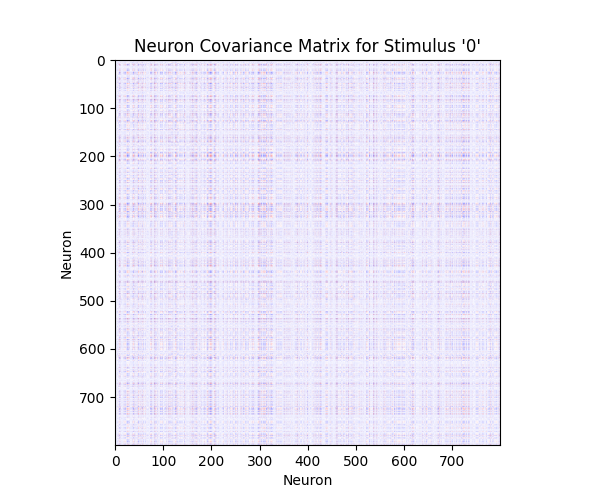

In [28]:
plt.figure(figsize=(6,5))
plt.imshow(X_cov, cmap="bwr")
plt.title(f"Neuron Covariance Matrix for Stimulus '{stim}'")
plt.xlabel("Neuron")
plt.ylabel("Neuron")
plt.show()

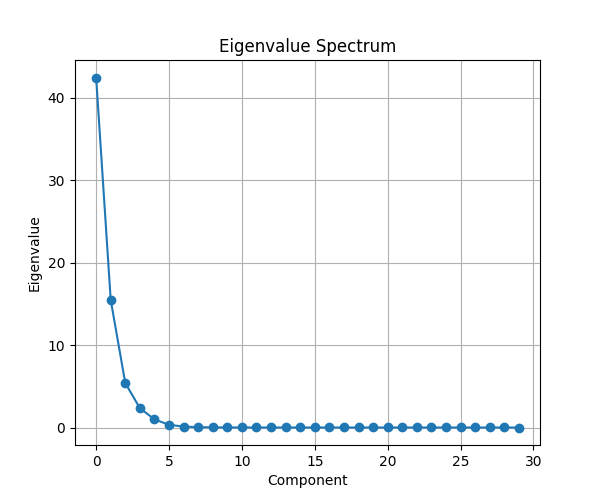

In [29]:
plt.figure(figsize=(6, 5))
eigvals = np.linalg.eigvalsh(X_cov)
plt.plot(sorted(eigvals, reverse=True)[:30], marker='o')
plt.title("Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.grid(True)

### Time-evolving neural dynamics

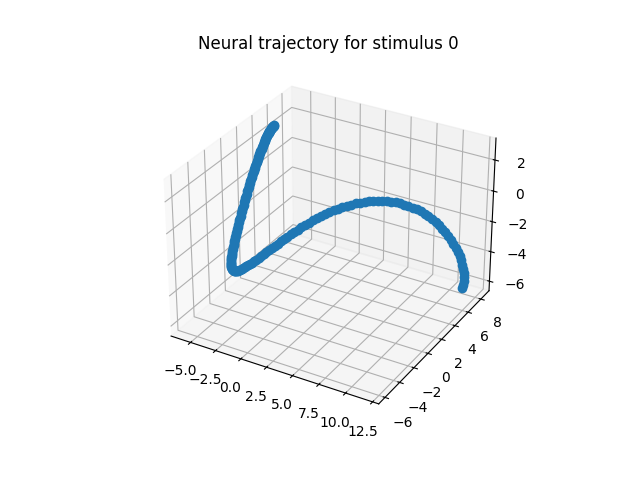

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X) # shape: (timesteps, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot(X_pca[:, 0], X_pca[:,1], X_pca[:, 2], marker="o")
ax.set_title(f"Neural trajectory for stimulus {stim}")
plt.show()

### How neural activity changes across phases?

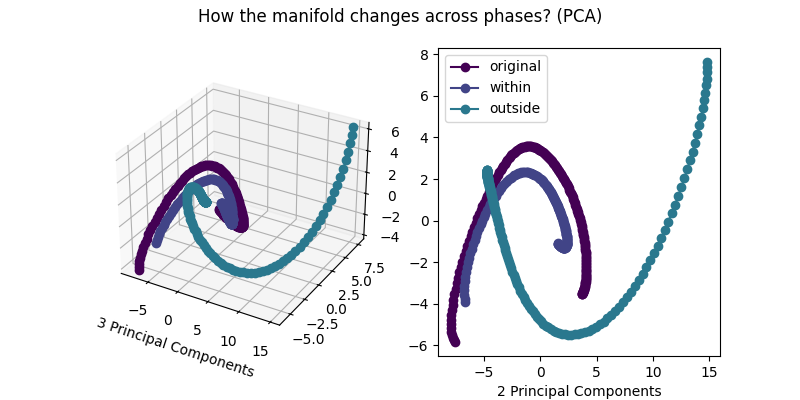

In [ ]:
# stim = 5
X = np.zeros((3, 180, 800))

for i, phase in enumerate(("original", "within", "outside")):
  # trial_crit = manifold[phase]["order"] == stim
  mean_activity = manifold[phase]["activity"][trial_crit, :, :].mean(axis=0)
  X[i, :] = mean_activity

fig = plt.figure(figsize=(8, 4))
fig.suptitle("How the manifold changes across phases? (PCA)")
ax3d = fig.add_subplot(121, projection="3d")
ax3d.set_xlabel("3 Principal Components")
ax2d = fig.add_subplot(122)
ax2d.set_xlabel("2 Principal Components")
cm = plt.get_cmap("viridis", 6)
phases = ("original", "within", "outside")

labels = {
  "original": "Original Manifold",
  "within": "Within Manifold Perturbation",
  "outside": "Outside Manifold Perturbation",
}
for i, stim_x in enumerate(X):
  pca = PCA(n_components=3)
  x_pca = pca.fit_transform(stim_x)
  ax3d.plot(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], marker="o", color=cm(i), label=phases[i])
  ax2d.plot(x_pca[:, 0], x_pca[:, 1], marker="o", color=cm(i), label=phases[i])
plt.legend()

plt.savefig("manifold_phases_pca.png", dpi=300)
plt.show()

### Stimulus-wise 